In [4]:
import sys
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', 'lightgbm'], check=True)

CompletedProcess(args=['c:\\Users\\syeda\\miniconda3\\python.exe', '-m', 'pip', 'install', 'xgboost', 'lightgbm'], returncode=0)

In [5]:
import pandas as pd
import numpy as np
import json
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

X = pd.read_csv('../data/processed/features_final.csv')
y = pd.read_csv('../data/processed/rul_labels.csv').squeeze()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", list(X.columns))

X shape: (100, 8)
y shape: (100,)
Features: ['value__sum_values', 'value__number_peaks__n_50', 'value__fft_coefficient__attr_"abs"__coeff_1', 'value__fft_coefficient__attr_"abs"__coeff_91', 'value__fft_coefficient__attr_"abs"__coeff_7', 'value__fft_coefficient__attr_"angle"__coeff_96', 'value__fft_coefficient__attr_"angle"__coeff_87', 'value__fft_coefficient__attr_"real"__coeff_96']


In [7]:
import re

# Clean column names - remove special characters
def clean_col_name(col):
    col = re.sub(r'["\(\)]', '', col)  # remove quotes and brackets
    col = re.sub(r'[^a-zA-Z0-9_]', '_', col)  # replace special chars with _
    col = re.sub(r'_+', '_', col)  # collapse multiple underscores
    return col.strip('_')

X.columns = [clean_col_name(c) for c in X.columns]
print("Cleaned feature names:")
for c in X.columns:
    print(" ", c)

Cleaned feature names:
  value_sum_values
  value_number_peaks_n_50
  value_fft_coefficient_attr_abs_coeff_1
  value_fft_coefficient_attr_abs_coeff_91
  value_fft_coefficient_attr_abs_coeff_7
  value_fft_coefficient_attr_angle_coeff_96
  value_fft_coefficient_attr_angle_coeff_87
  value_fft_coefficient_attr_real_coeff_96


In [8]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':             XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM':            LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')
    rmse = -scores.mean()
    std  = scores.std()
    results[name] = {'RMSE': round(rmse, 2), 'STD': round(std, 2)}
    print(f"{name:25s} → RMSE: {rmse:.2f} (±{std:.2f})")

Random Forest             → RMSE: 6.78 (±2.14)
Gradient Boosting         → RMSE: 6.35 (±2.73)
XGBoost                   → RMSE: 6.53 (±0.37)
LightGBM                  → RMSE: 19.59 (±3.13)


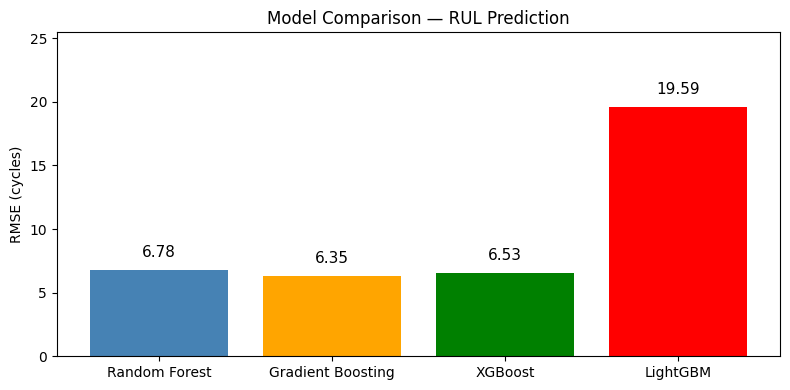

In [9]:
names = list(results.keys())
rmses = [results[m]['RMSE'] for m in names]

plt.figure(figsize=(8, 4))
bars = plt.bar(names, rmses, color=['steelblue','orange','green','red'])
plt.ylabel('RMSE (cycles)')
plt.title('Model Comparison — RUL Prediction')
plt.ylim(0, max(rmses) * 1.3)

# Add value labels on bars
for bar, val in zip(bars, rmses):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 1, 
             str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()

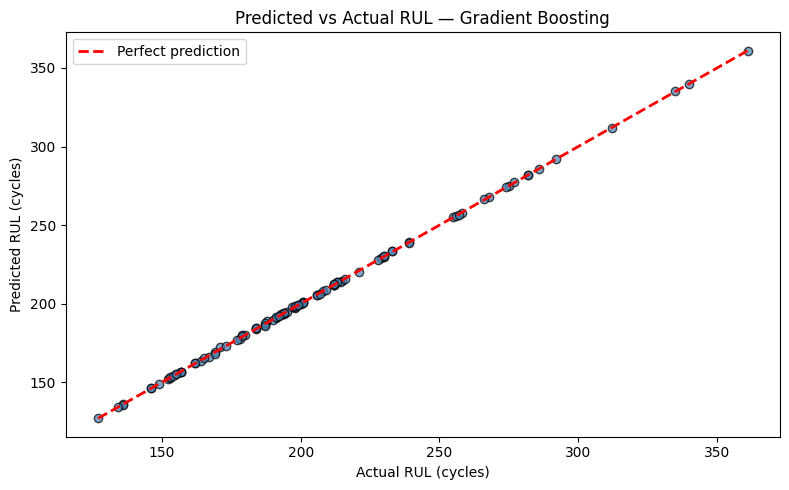

Model saved!


In [11]:
import joblib, os 

# Train best model on full data
best_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
best_model.fit(X, y)

# Predict
y_pred = best_model.predict(X)

# Plot predicted vs actual
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred, alpha=0.7, color='steelblue', edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title('Predicted vs Actual RUL — Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/predicted_vs_actual.png')
plt.show()

# Save model
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_model.pkl')
print("Model saved!")

In [12]:
import os

final_metrics = {
    'best_model': 'Gradient Boosting',
    'cv_rmse': 6.35,
    'cv_std': 2.73,
    'n_features_used': 8,
    'all_models': results
}

with open('../outputs/final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print("Metrics saved!")
print(json.dumps(final_metrics, indent=2))

Metrics saved!
{
  "best_model": "Gradient Boosting",
  "cv_rmse": 6.35,
  "cv_std": 2.73,
  "n_features_used": 8,
  "all_models": {
    "Random Forest": {
      "RMSE": 6.78,
      "STD": 2.14
    },
    "Gradient Boosting": {
      "RMSE": 6.35,
      "STD": 2.73
    },
    "XGBoost": {
      "RMSE": 6.53,
      "STD": 0.37
    },
    "LightGBM": {
      "RMSE": 19.59,
      "STD": 3.13
    }
  }
}


## Notebook 04 — Model Training and Evaluation

### Objective
Train and compare multiple regression models to predict Remaining Useful Life (RUL)
using the 8 features selected by the Genetic Algorithm in Notebook 03.

### Models Compared
| Model | CV RMSE | Std |
|-------|---------|-----|
| Random Forest | 6.78 | ±2.14 |
| Gradient Boosting | 6.35 | ±2.73 |
| XGBoost | 6.53 | ±0.37 |
| LightGBM | 19.59 | ±3.13 |

### Key Findings
- Gradient Boosting achieved the lowest RMSE of 6.35 cycles
- XGBoost was the most consistent with lowest variance (±0.37)
- LightGBM underperformed due to small dataset size (100 engines)
- Only 8 features were needed to achieve strong predictive performance

### Evaluation Method
- 5-fold cross validation on 100 engines
- Primary metric: RMSE (Root Mean Squared Error) in cycles
- Lower RMSE = predictions closer to true RUL

### Outputs
- `outputs/model_comparison.png` — bar chart of RMSE per model
- `outputs/predicted_vs_actual.png` — scatter plot of predictions vs true RUL
- `outputs/final_metrics.json` — all metrics saved
- `models/best_model.pkl` — saved Gradient Boosting model